In [2]:
import os
import cv2
import random
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from scipy.ndimage import rotate

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# Folder path
image_folder = '/kaggle/input/arabic-ocr/Total Images Processed'

# Get and sort image filenames by name (not timestamp)
image_filenames = sorted([
    f for f in os.listdir(image_folder)
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'))
])

# Load images
images = []
for filename in image_filenames:
    img_path = os.path.join(image_folder, filename)
    img = cv2.imread(img_path)
    if img is not None:
        images.append(img)
    else:
        print(f"Warning: Could not load {filename}")

# Display first 10 images in order
plt.figure(figsize=(18, 6))
for i in range(min(10, len(images))):
    img_rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Image {i+1}", fontsize=10)

plt.tight_layout()
plt.show()

# Print total images and first 5 filenames for verification
print("Total images loaded:", len(images))
print("First 5 image filenames:")
for name in image_filenames[:5]:
    print(name)


In [4]:
def load_labels_from_folder(folder):
    labels = []
    # Sort the filenames to maintain a consistent order
    filenames = sorted(os.listdir(folder))
    for filename in filenames:
        # Read inside txt files
        with open(os.path.join(folder, filename), 'r', encoding='utf-8') as f:
            label = f.read()
        labels.append(label)
    return labels

labels = load_labels_from_folder(r'/kaggle/input/arabic-ocr/Total GT Processed')
print(len(labels))
# Print first 5 labels
print(labels[0:10])

15477
['أت', 'ظافر', 'ظافر', 'ظافر', 'يق', 'يق', 'يق', 'را', 'را', 'را']


In [5]:
images[0].shape

(32, 64, 3)

In [6]:
images[2].shape

(37, 66, 3)

In [7]:
# resize images to 32x64
resized_images = []
for img in images:
    img = cv2.resize(img, (64, 32))
    resized_images.append(img)

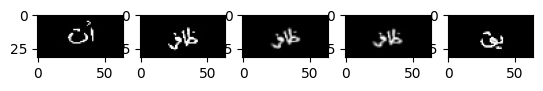

In [8]:
#show first 5 images using plt subplot
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(resized_images[i])


dealing with labels

In [10]:
def clean_labels(labels):
    cleaned_labels = []
    for label in labels:
        label = label.split(" ")[-1].strip()
        cleaned_labels.append(label)
    return cleaned_labels

In [11]:
labels_cleaned = clean_labels(labels)

In [12]:
# select only the images with labels cleaned
resized_images = [img for img, label in zip(resized_images, labels_cleaned) if label]
labels = [label for label in labels_cleaned if label]

In [13]:
from tensorflow.keras.layers import StringLookup
max_len = 0
characters = set()
for label in labels:
    label = label.split(" ")[-1].strip()
    for char in label:
        characters.add(char)

    max_len = max(max_len, len(label))

print("Maximum length: ", max_len)
print("Vocab size: ", len(characters))

Maximum length:  7
Vocab size:  39


In [14]:
print(characters)

{'ٍ', 'د', 'آ', 'ء', 'أ', 'ق', 'ل', 'ي', 'ئ', 'س', 'ظ', 'ف', 'ت', 'ر', 'ع', 'ج', '،', 'ا', 'إ', 'ز', 'ه', 'ب', 'غ', 'ح', 'ك', '.', 'م', 'ؤ', 'ث', 'ص', 'ن', 'و', 'خ', 'ش', 'ة', 'ض', 'ط', 'ذ', ':'}


In [16]:
AUTOTUNE = tf.data.AUTOTUNE

# Mapping characters to integers.
char_to_num = StringLookup(vocabulary=list(characters), mask_token=None)

# Mapping integers back to original characters.
num_to_char = StringLookup(
    vocabulary=char_to_num.get_vocabulary(), mask_token=None, invert=True
)

In [17]:
padding_token = 99

def vectorize_label(label):
    print(label)
    label = char_to_num(tf.strings.unicode_split(label, input_encoding="UTF-8"))
    length = tf.shape(label)[0]
    pad_amount = max_len - length
    label = tf.pad(label, paddings=[[0, pad_amount]], constant_values=padding_token)
    return label



In [18]:
label1=vectorize_label(labels[0])
print(label1)
indices = tf.gather(label1, tf.where(tf.math.not_equal(label1, padding_token)))
label1 = tf.strings.reduce_join(num_to_char(indices))
label1 = label1.numpy().decode("utf-8")
print(label1)

أت
tf.Tensor([ 5 13 99 99 99 99 99], shape=(7,), dtype=int64)
أت


In [19]:
def devectorize_label(label):
    # Remove padding tokens
    label = label[label != padding_token]
    
    # Convert label indices back to characters
    characters = [char_to_num.get_vocabulary()[idx] for idx in label]
    
    # Concatenate characters to form the original text
    original_text = ''.join(characters)
    
    return original_text

In [20]:
len(resized_images)

15372

In [21]:
len(labels)

15372

In [22]:
labels_v = [vectorize_label(i) for i in labels]
# #load labels vectorized
# labels_v = np.load('labels_v.npy')

أت
ظافر
ظافر
ظافر
يق
يق
يق
را
را
را
ي
ي
ي
لؤ
لؤ
لؤ
بن
بن
بن
رؤوف
رؤوف
رؤوف
بصحبة
بصحبة
بصحبة
م
م
م
ضرغا
ضرغا
ضرغا
أت
أت
بد
مظفر
مظفر
مظفر
نوح
نوح
نوح
ذهب
ذهب
ذهب
بد
بد
.
.
.
للحج
للحج
للحج
عفيف
عفيف
عفيف
ن
ن
ن
خاز
خاز
خاز
وهلال
وهلال
وهلال
عطعوط
عطعوط
عطعوط
وهو
و
و
و
طفنا
طفنا
طفنا
لنا
لنا
لنا
وصو
وصو
وصو
عند
عند
عند
.
.
.
يلبي
يلبي
يلبي
آخر
آخر
آخر
ثر
ثر
ثر
إ
إ
إ
وهو
وهو
حاج
حاج
حاج
في
في
في
جاري
جاري
جاري
كان
كان
كان
.
.
.
شيخ
شيخ
شيخ
مع
مع
مع
سعينا
سعينا
سعينا
.
رايق
رايق
رايق
ي
ي
ي
لؤ
لؤ
لؤ
بن
بن
بن
.
.
.
رؤوف
رؤوف
رؤوف
بصحبة
بصحبة
بصحبة
م
م
م
ضرغا
ضرغا
ضرغا
مظفر
مظفر
مظفر
.
.
للحج
نوح
نوح
نوح
هب
هب
هب
ذ
ذ
ذ
للحج
للحج
عفيف
عفيف
عفيف
خازن
خازن
خازن
ل
ل
ل
وهلا
وهلا
وهلا
عطعوط
عطعوط
عطعوط
فر
فر
فر
ظا
ظا
ظا
الخيمة
وصولنا
وصولنا
وصولنا
عند
عند
عند
.
.
.
يلبي
يلبي
يلبي
آخر
آخر
آخر
إ
إ
إ
حاج
حاج
حاج
لحجيج
لحجيج
لحجيج
ا
ا
ا
قوافل
قوافل
قوافل
الخيمة
الخيمة
في
أت
أت
أت
بد
بد
بد
في
في
جاري
جاري
جاري
كان
كان
كان
.
.
.
شيخ
شيخ
شيخ
مع
مع
مع
وسعينا
وسعينا
وسعينا
طفنا
طفنا
طفنا
.
دراق
دراق
دراق
،


In [23]:
labels_cleaned

['أت',
 'ظافر',
 'ظافر',
 'ظافر',
 'يق',
 'يق',
 'يق',
 'را',
 'را',
 'را',
 'ي',
 'ي',
 'ي',
 'لؤ',
 'لؤ',
 'لؤ',
 'بن',
 'بن',
 'بن',
 'رؤوف',
 'رؤوف',
 'رؤوف',
 'بصحبة',
 'بصحبة',
 'بصحبة',
 'م',
 'م',
 'م',
 'ضرغا',
 'ضرغا',
 'ضرغا',
 'أت',
 'أت',
 'بد',
 'مظفر',
 'مظفر',
 'مظفر',
 'نوح',
 'نوح',
 'نوح',
 'ذهب',
 'ذهب',
 'ذهب',
 'بد',
 'بد',
 '.',
 '.',
 '.',
 'للحج',
 'للحج',
 'للحج',
 'عفيف',
 'عفيف',
 'عفيف',
 'ن',
 'ن',
 'ن',
 'خاز',
 'خاز',
 'خاز',
 'وهلال',
 'وهلال',
 'وهلال',
 'عطعوط',
 'عطعوط',
 'عطعوط',
 'وهو',
 'و',
 'و',
 'و',
 'طفنا',
 'طفنا',
 'طفنا',
 'لنا',
 'لنا',
 'لنا',
 'وصو',
 'وصو',
 'وصو',
 'عند',
 'عند',
 'عند',
 '.',
 '.',
 '.',
 'يلبي',
 'يلبي',
 'يلبي',
 'آخر',
 'آخر',
 'آخر',
 'ثر',
 'ثر',
 'ثر',
 'إ',
 'إ',
 'إ',
 'وهو',
 'وهو',
 'حاج',
 'حاج',
 'حاج',
 'في',
 'في',
 'في',
 'جاري',
 'جاري',
 'جاري',
 'كان',
 'كان',
 'كان',
 '.',
 '.',
 '.',
 'شيخ',
 'شيخ',
 'شيخ',
 'مع',
 'مع',
 'مع',
 'سعينا',
 'سعينا',
 'سعينا',
 '.',
 'رايق',
 'رايق',
 'رايق',
 'ي',
 

END

عند


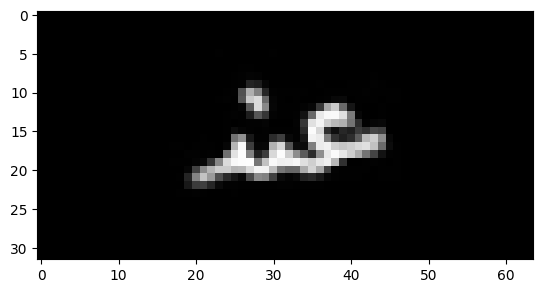

In [76]:
#show a random image and its label
ran = random.randint(0,len(images))
plt.imshow(resized_images[ran])
#print 3rd label
print(labels[ran])

In [26]:
labels_de_v = [devectorize_label(label) for label in labels_v]
# load labels devectorized
# labels_de_v = np.load('labels_de_v.npy')

In [27]:
len(labels_de_v)

15372

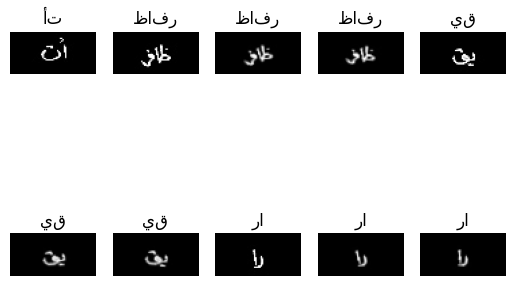

In [28]:
#show first 10 images using plt with their repective decoded labels
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(resized_images[i], cmap='gray')
    plt.title(labels_de_v[i])
    plt.axis('off')
plt.show()

In [29]:
len(labels_de_v)

15372

In [30]:
len(resized_images)

15372

In [31]:
# reshape data
resized_images = np.array(resized_images)
resized_images.shape

(15372, 32, 64, 3)

In [32]:
#create a train test split of 80:20
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(resized_images, labels_v, test_size=0.2, random_state=42)
#Create a validation set
# X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.15, random_state=30)

In [33]:
y_train = np.array(y_train)
# y_val = np.array(y_val)
y_test = np.array(y_test)

In [100]:
class CTCLayer(keras.layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.loss_fn = tf.keras.backend.ctc_batch_cost
        
    def call(self, y_true, y_pred):
        # Ensure inputs have consistent types
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        # Get batch size and sequence lengths
        batch_len = tf.shape(y_true)[0]
        input_length = tf.shape(y_pred)[1]
        label_length = tf.shape(y_true)[1]
        
        # Create tensors of appropriate shapes
        input_length = tf.fill([batch_len, 1], input_length)
        label_length = tf.fill([batch_len, 1], label_length)
        
        # Calculate CTC loss with explicit casting
        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        
        # Ensure loss is float32 regardless of mixed precision policy
        loss = tf.cast(loss, tf.float32)
        self.add_loss(loss)
        
        return y_pred

VGG19

In [90]:
from tensorflow.keras.applications import ResNet152

base = ResNet152(weights=None, include_top=False, input_shape=(32, 64, 3))
base.summary()

Model: "resnet152"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 32, 64, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cast_7 (Cast)             │ (None, 32, 64, 3)      │              0 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 38, 70, 3)      │              0 │ cast_7[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 16, 32, 64)     │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 16, 32, 64)     │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 16, 32, 64)     │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 18, 34, 64)     │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 8, 16, 64)      │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 8, 16, 64)      │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 8, 16, 64)      │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 8, 16, 64)      │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 8, 16, 64)      │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 8, 16, 64)      │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 8, 16, 64)      │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 8, 16, 256)     │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 58,370,944 (222.67 MB)

 Trainable params: 58,219,520 (222.09 MB)

 Non-trainable params: 151,424 (591.50 KB)

In [103]:
def build_model():
    # Inputs to the model
    input_img = keras.Input(shape=(32, 64, 3), name="image")
    labels = keras.layers.Input(name="label", shape=(None,))
    
    # Custom CNN backbone
    x = input_img
    
    # First block
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)  # 16x32
    x = BatchNormalization()(x)
    
    # Second block
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)  # 8x16
    x = BatchNormalization()(x)
    
    # Third block - modified to preserve width more
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((1, 2))(x)  # 8x8
    x = BatchNormalization()(x)
    
    # Calculate the correct reshape dimensions
    # Current shape is (8, 8, 128) = 8,192 elements
    # We can reshape to (64, 128) which has the same number of elements
    x = Reshape((64, 128))(x)  # Fixed: 8×8×128 = 64×128 = 8,192 elements
    
    # Dense and LSTM layers
    x = Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    
    # Adjust LSTM layers for the new sequence length (64)
    x = Bidirectional(LSTM(256, return_sequences=True, dropout=0.3))(x)
    x = Bidirectional(LSTM(256, return_sequences=True, dropout=0.3))(x)
    
    # Output layer
    vocab_size = len(char_to_num.get_vocabulary()) + 2
    x = Dense(vocab_size, activation="softmax")(x)
   
    output = CTCLayer(name="ctc_loss")(labels, x)
    
    model = keras.models.Model(inputs=[input_img, labels], outputs=output, name="Handwriting_OCR")
    
    # Optimizer with gradient clipping
    opt = keras.optimizers.Nadam(
        learning_rate=0.0005,
        beta_1=0.9, 
        beta_2=0.999, 
        epsilon=1e-08,
        clipnorm=1.0
    )
    
    model.compile(optimizer=opt)
    return model

In [104]:
model = build_model()

model.summary()

Model: "Handwriting_OCR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)        │ (None, 32, 64, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cast_11 (Cast)            │ (None, 32, 64, 3)      │              0 │ image[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_30 (Conv2D)        │ (None, 32, 64, 32)     │            896 │ cast_11[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_31 (Conv2D)        │ (None, 32, 64, 32)     │          9,248 │ conv2d_30[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_15          │ (None, 16, 32, 32)     │              0 │ conv2d_31[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_20    │ (None, 16, 32, 32)     │            128 │ max_pooling2d_15[0][0] │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_32 (Conv2D)        │ (None, 16, 32, 64)     │         18,496 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_33 (Conv2D)        │ (None, 16, 32, 64)     │         36,928 │ conv2d_32[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_16          │ (None, 8, 16, 64)      │              0 │ conv2d_33[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_21    │ (None, 8, 16, 64)      │            256 │ max_pooling2d_16[0][0] │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_34 (Conv2D)        │ (None, 8, 16, 128)     │         73,856 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_35 (Conv2D)        │ (None, 8, 16, 128)     │        147,584 │ conv2d_34[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_17          │ (None, 8, 8, 128)      │              0 │ conv2d_35[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_22    │ (None, 8, 8, 128)      │            512 │ max_pooling2d_17[0][0] │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_6 (Reshape)       │ (None, 64, 128)        │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 64, 256)        │         33,024 │ reshape_6[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2

 Total params: 2,969,034 (11.33 MB)

 Trainable params: 2,968,074 (11.32 MB)

 Non-trainable params: 960 (3.75 KB)

In [105]:
 from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=0.00001)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.h5",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)


In [106]:
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

In [111]:
# Train the model
history = model.fit([X_train, y_train], epochs=200, validation_data=([X_test, y_test],None),batch_size=128, callbacks=[lr_scheduler, checkpoint])

Epoch 1/200
96/97 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 159.8568
Epoch 1: val_loss did not improve from 285.29779
97/97 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - loss: 159.7975 - val_loss: 400.7538 - learning_rate: 5.0000e-04
Epoch 2/200
96/97 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 139.1154
Epoch 2: val_loss improved from 285.29779 to 284.91849, saving model to best_model.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - loss: 139.1523 - val_loss: 284.9185 - learning_rate: 5.0000e-04
Epoch 3/200
96/97 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 124.6693
Epoch 3: val_loss improved from 284.91849 to 222.19792, saving model to best_model.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - loss: 124.7382 - val_loss: 222.1979 - learning_rate: 5.0000e-04
Epoch 4/200
96/97 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 117.4315
Epoch 4: val_loss did not improve from 222.19792
97/97 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - loss: 117.4918 - val_loss: 256.0144 - learning_rate: 5.0000e-04
Epoch 5/200
96/97 ━━━━

In [113]:
model.save('/kaggle/working/Paper_Resnet512-WP-f.h5')


In [114]:
# Evaluate the model
model.evaluate([X_test, y_test])

97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 19.8123


21.951601028442383

In [115]:

# predict 
y_pred = model.predict([X_test, y_test])

97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step


In [116]:
y_pred

array([[[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 5.9604645e-08],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 1.1920929e-07],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 2.3059845e-03],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 1.1920929e-07],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 5.3644180e-07]],

       [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 1.7881393e-07],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 1.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.000

In [117]:
y_test

array([[18,  7, 24, ..., 99, 99, 99],
       [ 7, 18, 99, ..., 99, 99, 99],
       [26, 99, 99, ..., 99, 99, 99],
       ...,
       [14, 32, 28, ..., 99, 99, 99],
       [ 7, 13, 18, ..., 99, 99, 99],
       [ 7, 21, 99, ..., 99, 99, 99]])

In [120]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K  # <-- Correct import

def decode_batch_predictions(pred, max_len):
    # pred: output of the model (after softmax)
    
    input_len = np.ones(pred.shape[0]) * pred.shape[1]

    # CTC decode: returns tuple (decoded_sequences, log_probabilities)
    results = K.ctc_decode(pred, input_length=input_len, greedy=True)[0][0][:, :max_len]

    output_text = []
    for res in results:
        # Remove padding -1 values
        res = tf.gather(res, tf.where(tf.math.not_equal(res, -1)))
        # Decode using num_to_char (should be a tf.lookup or a callable)
        res = tf.strings.reduce_join(num_to_char(res)).numpy().decode("utf-8")
        output_text.append(res)
    
    print(output_text)
    return output_text


In [122]:
max_len = y_pred.shape[1]  # Assuming the model output has shape (batch_size, time_steps, num_classes)
y_pred_text = decode_batch_predictions(y_pred, max_len)


['الحج', 'لا', '.', 'قوا', 'ش', 'ث', 'يلبي', 'فا', 'ش', 'ئم', 'را', 'ز', 'ت', 'ر', 'ا', 'نقض', '،', 'تعلم', 'هل', 'جاري', '.', 'عطعو', 'ئم', 'مثل', '.', 'نقض', 'عند', 'هل', 'ي', 'س', 'ا', 'بن', 'ع', 'آخر', 'للحج', 'وصولنا', '.', 'خر', 'يلبي', 'فر', 'ا', 'وهو', '،', '.', 'آخر', 'رايق', 'ي', 'يق', 'بفلس', 'فل', 'ذ', 'نا', '.', 'ح', 'ب', 'هلا', 'للحج', 'خ', 'نقض', 'ضر', 'طفنا', 'ئد', 'ذ', 'يتكلم', 'ثر', 'أت', 'وهو', 'ضرغا', 'لنا', 'فهمها', 'في', '.', 'ت', 'ري', 'ا', 'ا', '.', 'رؤوف', '.', 'ظافر', 'ب', 'ثر', 'ر', 'و', 'ف', '،', 'ر', 'خار', 'لضا', '،', 'نا', ':', 'ظ', 'بنا', 'لهذ', 'لكلما', 'مشمش', 'م', 'الكلما', 'حا', 'ا', 'ري', '،', 'ذ', 'ع', '', 'عو', 'ط', 'هلا', 'قو', 'في', 'ا', 'للحج', 'ا', 'ر', 'شيخغ', 'لؤ', 'بفلس', '.', 'بكلما', 'آا', 'الشيخ', 'رؤو', 'وصونا', 'نا', 'راجح', 'بصحبة', 'بلغ', 'ا', 'را', 'ا', 'لية', 'بنا', 'ا', 'لخيمة', 'عفيف', 'رايق', 'و', 'ج', 'فل', 'ه', 'في', 'ا', 'زن', '،', 'طفنا', 'ر', 'أ', 'ا', 'خ', 'ا', 'لتا', 'يق', 'ع', 'عطعو', 'لزمتك', 'في', '.', 'في', 'النص', 'ع

In [125]:
y_pred_text = decode_batch_predictions(y_pred, max_len)


['الحج', 'لا', '.', 'قوا', 'ش', 'ث', 'يلبي', 'فا', 'ش', 'ئم', 'را', 'ز', 'ت', 'ر', 'ا', 'نقض', '،', 'تعلم', 'هل', 'جاري', '.', 'عطعو', 'ئم', 'مثل', '.', 'نقض', 'عند', 'هل', 'ي', 'س', 'ا', 'بن', 'ع', 'آخر', 'للحج', 'وصولنا', '.', 'خر', 'يلبي', 'فر', 'ا', 'وهو', '،', '.', 'آخر', 'رايق', 'ي', 'يق', 'بفلس', 'فل', 'ذ', 'نا', '.', 'ح', 'ب', 'هلا', 'للحج', 'خ', 'نقض', 'ضر', 'طفنا', 'ئد', 'ذ', 'يتكلم', 'ثر', 'أت', 'وهو', 'ضرغا', 'لنا', 'فهمها', 'في', '.', 'ت', 'ري', 'ا', 'ا', '.', 'رؤوف', '.', 'ظافر', 'ب', 'ثر', 'ر', 'و', 'ف', '،', 'ر', 'خار', 'لضا', '،', 'نا', ':', 'ظ', 'بنا', 'لهذ', 'لكلما', 'مشمش', 'م', 'الكلما', 'حا', 'ا', 'ري', '،', 'ذ', 'ع', '', 'عو', 'ط', 'هلا', 'قو', 'في', 'ا', 'للحج', 'ا', 'ر', 'شيخغ', 'لؤ', 'بفلس', '.', 'بكلما', 'آا', 'الشيخ', 'رؤو', 'وصونا', 'نا', 'راجح', 'بصحبة', 'بلغ', 'ا', 'را', 'ا', 'لية', 'بنا', 'ا', 'لخيمة', 'عفيف', 'رايق', 'و', 'ج', 'فل', 'ه', 'في', 'ا', 'زن', '،', 'طفنا', 'ر', 'أ', 'ا', 'خ', 'ا', 'لتا', 'يق', 'ع', 'عطعو', 'لزمتك', 'في', '.', 'في', 'النص', 'ع

In [126]:
# devectorize the labels
y_test_texts = [devectorize_label(label) for label in y_test]

In [127]:
y_pred_text

['الحج',
 'لا',
 '.',
 'قوا',
 'ش',
 'ث',
 'يلبي',
 'فا',
 'ش',
 'ئم',
 'را',
 'ز',
 'ت',
 'ر',
 'ا',
 'نقض',
 '،',
 'تعلم',
 'هل',
 'جاري',
 '.',
 'عطعو',
 'ئم',
 'مثل',
 '.',
 'نقض',
 'عند',
 'هل',
 'ي',
 'س',
 'ا',
 'بن',
 'ع',
 'آخر',
 'للحج',
 'وصولنا',
 '.',
 'خر',
 'يلبي',
 'فر',
 'ا',
 'وهو',
 '،',
 '.',
 'آخر',
 'رايق',
 'ي',
 'يق',
 'بفلس',
 'فل',
 'ذ',
 'نا',
 '.',
 'ح',
 'ب',
 'هلا',
 'للحج',
 'خ',
 'نقض',
 'ضر',
 'طفنا',
 'ئد',
 'ذ',
 'يتكلم',
 'ثر',
 'أت',
 'وهو',
 'ضرغا',
 'لنا',
 'فهمها',
 'في',
 '.',
 'ت',
 'ري',
 'ا',
 'ا',
 '.',
 'رؤوف',
 '.',
 'ظافر',
 'ب',
 'ثر',
 'ر',
 'و',
 'ف',
 '،',
 'ر',
 'خار',
 'لضا',
 '،',
 'نا',
 ':',
 'ظ',
 'بنا',
 'لهذ',
 'لكلما',
 'مشمش',
 'م',
 'الكلما',
 'حا',
 'ا',
 'ري',
 '،',
 'ذ',
 'ع',
 '',
 'عو',
 'ط',
 'هلا',
 'قو',
 'في',
 'ا',
 'للحج',
 'ا',
 'ر',
 'شيخغ',
 'لؤ',
 'بفلس',
 '.',
 'بكلما',
 'آا',
 'الشيخ',
 'رؤو',
 'وصونا',
 'نا',
 'راجح',
 'بصحبة',
 'بلغ',
 'ا',
 'را',
 'ا',
 'لية',
 'بنا',
 'ا',
 'لخيمة',
 'عفيف',
 'رايق',
 '

In [128]:
y_test_texts

['الحج',
 'لا',
 '.',
 'قوا',
 'ش',
 'ث',
 'يلبي',
 'فا',
 'ش',
 'ئم',
 'را',
 'ز',
 'ت',
 'ر',
 'ا',
 'نقض',
 '،',
 'تعلم',
 'هل',
 'جاري',
 '.',
 'عطعو',
 'ئم',
 'مثل',
 '.',
 'نقض',
 'عند',
 'هل',
 'ي',
 'س',
 'ا',
 'بن',
 'ع',
 'آخر',
 'للحج',
 'وصولنا',
 '.',
 'خر',
 'يلبي',
 'فر',
 'ا',
 'وهو',
 '،',
 '.',
 'آخر',
 'رايق',
 'ي',
 'يق',
 'بفلس',
 'فل',
 'ذ',
 'فا',
 '.',
 'ح',
 'ب',
 'هلا',
 'للحج',
 'خ',
 'نقض',
 'ضر',
 'طفنا',
 'ثر',
 'ذ',
 'يتكلم',
 'ثر',
 'أت',
 'وهو',
 'ضرغا',
 'لنا',
 'فهمها',
 'في',
 '.',
 'ت',
 'ري',
 'ا',
 'ا',
 '.',
 'رؤوف',
 '.',
 'ظافر',
 'ب',
 'ثر',
 'ر',
 'و',
 'في',
 '،',
 'ر',
 'خار',
 'لضا',
 '،',
 'نا',
 ':',
 'ظ',
 'بنا',
 'لهذ',
 'الكلما',
 'مشمش',
 'م',
 'الكلما',
 'حا',
 'ا',
 'ري',
 '،',
 'ذ',
 'ع',
 'ر',
 'ع',
 'ط',
 'هلا',
 'قو',
 'في',
 'ا',
 'للحج',
 'ا',
 'بدأ',
 'شيخ',
 'لؤ',
 'بفلس',
 '.',
 'بكلما',
 'را',
 'الشيخ',
 'رؤوف',
 'وصولنا',
 'نا',
 'راجح',
 'بصحبة',
 'بلغ',
 'ا',
 'را',
 'ا',
 'لؤي',
 'بنا',
 'ا',
 'لخيمة',
 'عفيف',
 'رايق

In [129]:
# save y_pred_text as a whole txt file
with open('/kaggle/working/y_pred_text.txt', 'w', encoding='utf-8') as f:
    for item in y_pred_text:
        f.write("%s\n" % item)

In [130]:
# save y_test_texts as a whole txt file
with open('/kaggle/working/y_test_texts.txt', 'w', encoding='utf-8') as f:
    for item in y_test_texts:
        f.write("%s\n" % item)